In [1]:
import anndata as ad
import decoupler as dc
import mofax as mfx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.stats.multitest as multitest
from scipy.stats import mannwhitneyu

KeyboardInterrupt: 

In [ ]:
import requests
import os

prism_24q2_article_id = '25917643'
prism_19q4_article_id = '9393293'
crispr_article_id = '25880521'
ruta_salida = "/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/"

for article_id, nombres in [
    (prism_24q2_article_id, [
        'Repurposing_Public_24Q2_LFC.csv',
        'Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv',
        'Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv',
        'Repurposing_Public_24Q2_Treatment_Meta_Data.csv',
        'Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv'
    ]),
    (prism_19q4_article_id, [
        'secondary-screen-dose-response-curve-parameters.csv',
        'secondary-screen-cell-line-info.csv'
    ]),
    (crispr_article_id, ['CRISPRGeneDependency.csv'])
]:
    response = requests.get(f'https://api.figshare.com/v2/articles/{article_id}/files')
    files = response.json()
    for f in files:
        if f['name'] in nombres:
            print(f"Descargando {f['name']}...")
            r = requests.get(f['download_url'])
            with open(os.path.join(ruta_salida, f['name']), 'wb') as out:
                out.write(r.content)
            print(f"Guardado: {f['name']}")


In [2]:
ruta_salida = "/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/"

In [21]:
crispr = pd.read_csv(f"{ruta_salida}/CRISPRGeneDependency.csv",index_col=0)
curve_param = pd.read_csv(f"{ruta_salida}/secondary-screen-dose-response-curve-parameters.csv")
metadata_lcel = pd.read_csv(f"{ruta_salida}/Model.csv")

/tmp/ipykernel_2715152/1887969440.py:2: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  curve_param = pd.read_csv(f"{ruta_salida}/secondary-screen-dose-response-curve-parameters.csv")


In [33]:
PATH_ADATA = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad"
adata = ad.read_h5ad(PATH_ADATA)

factors = adata.uns["mofa_weights_factors"]
collectri = dc.get_collectri(organism="human")
tfs_of_interes = ["YAP1", "TEAD1", "TEAD2", "TEAD4", "WWTR1"]


# Calcular actividad de TFs YAP/TAZ por linea celular usando los pesos de MOFA
W = pd.DataFrame(
    adata.uns["mofa_weights"],
    index=adata.uns[f"mofa_weights_genes"],
    columns=factors
)
acts, pvals = dc.run_ulm(W.T, net=collectri, source="source", target="target", weight="weight")
acts_sig = acts.where((pvals < 0.05) & (acts < 0))
results = {
    "acts_sig": acts_sig[tfs_of_interes],
}
resultados = pd.DataFrame(results['acts_sig'])
resultados_mofa = resultados.dropna(how = 'all')

In [22]:
yap_col = [col for col in crispr.columns if col.startswith("YAP1")][0]
wwtr1_col = [col for col in crispr.columns if col.startswith("WWTR1")][0]
tead_cols = [col for col in crispr.columns if any(col.startswith(t) for t in ["TEAD1", "TEAD2", "TEAD4"])]

yap_dependent = crispr[
    (crispr[yap_col] > 0.5) |
    (crispr[wwtr1_col] > 0.5) |
    crispr[tead_cols].gt(0.5).any(axis=1)
].index.tolist()

yap_independent = [x for x in crispr.index if x not in yap_dependent]

print(f"Líneas YAP/TAZ-dependientes: {len(yap_dependent)}")
print(f"Líneas YAP/TAZ-independientes: {len(yap_independent)}")
print(f"Total: {len(yap_dependent) + len(yap_independent)}")

Líneas YAP/TAZ-dependientes: 619
Líneas YAP/TAZ-independientes: 531
Total: 1150


In [23]:
yap_dependent

['ACH-000001',
 'ACH-000007',
 'ACH-000009',
 'ACH-000011',
 'ACH-000013',
 'ACH-000015',
 'ACH-000017',
 'ACH-000018',
 'ACH-000021',
 'ACH-000023',
 'ACH-000025',
 'ACH-000026',
 'ACH-000029',
 'ACH-000030',
 'ACH-000036',
 'ACH-000040',
 'ACH-000042',
 'ACH-000054',
 'ACH-000060',
 'ACH-000067',
 'ACH-000082',
 'ACH-000086',
 'ACH-000090',
 'ACH-000092',
 'ACH-000093',
 'ACH-000094',
 'ACH-000096',
 'ACH-000097',
 'ACH-000098',
 'ACH-000103',
 'ACH-000108',
 'ACH-000114',
 'ACH-000116',
 'ACH-000118',
 'ACH-000127',
 'ACH-000128',
 'ACH-000132',
 'ACH-000133',
 'ACH-000137',
 'ACH-000138',
 'ACH-000141',
 'ACH-000142',
 'ACH-000144',
 'ACH-000147',
 'ACH-000152',
 'ACH-000153',
 'ACH-000155',
 'ACH-000160',
 'ACH-000163',
 'ACH-000174',
 'ACH-000176',
 'ACH-000181',
 'ACH-000188',
 'ACH-000189',
 'ACH-000191',
 'ACH-000192',
 'ACH-000200',
 'ACH-000207',
 'ACH-000208',
 'ACH-000209',
 'ACH-000211',
 'ACH-000212',
 'ACH-000213',
 'ACH-000215',
 'ACH-000216',
 'ACH-000217',
 'ACH-0002

In [24]:
metadata_lcel = metadata_lcel[['ModelID','OncotreeLineage']]
curve_param = curve_param[['broad_id','depmap_id','ccle_name','auc']]
curve_param

,broad_id,depmap_id,ccle_name,auc
0,BRD-K71847383-001-12-5,ACH-000879,MFE296_ENDOMETRIUM,1.677789
1,BRD-K71847383-001-12-5,ACH-000320,PSN1_PANCREAS,1.240300
2,BRD-K71847383-001-12-5,ACH-001145,OC316_OVARY,1.472333
3,BRD-K71847383-001-12-5,ACH-000873,KYSE270_OESOPHAGUS,1.207160
4,BRD-K71847383-001-12-5,ACH-000855,KYSE150_OESOPHAGUS,1.229332
...,...,...,...,...
700999,BRD-K96123349-236-02-8,ACH-001321,TT_THYROID,0.987409
701000,BRD-K98572433-001-02-9,ACH-001321,TT_THYROID,1.000000
701001,BRD-K99113996-001-02-0,ACH-001321,TT_THYROID,1.000000
701002,BRD-K99616396-001-05-1,ACH-001321,TT_THYROID,0.888088


In [25]:
df_yap_dependent = pd.DataFrame(yap_dependent, columns = ['ModelID'])
df_yap_independent = pd.DataFrame(yap_independent,columns=['ModelID'])
df_curve_param_ydep = pd.merge(df_yap_dependent,curve_param,left_on='ModelID',right_on='depmap_id', how='inner' )
df_curve_param_f_ydep =pd.merge(df_curve_param_ydep,metadata_lcel,on='ModelID',how='inner')
df_curve_param_noydep = pd.merge(df_yap_independent,curve_param,left_on='ModelID',right_on='depmap_id', how='inner' )
df_curve_param_f_noydep =pd.merge(df_curve_param_noydep,metadata_lcel,on='ModelID',how='inner')

In [27]:
metadata = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv")

rep_clean = metadata[['IDs', 'Drug.Name', 'MOA', 'Synonyms']].drop_duplicates('IDs').rename(columns={'IDs': 'broad_id'})

rep_clean['broad_id'] = rep_clean['broad_id'].str.replace('BRD:', '',regex=False)
print(rep_clean)


                    broad_id                Drug.Name  MOA  \
0     BRD-K00104122-001-01-9                 MRTX1133  NaN   
1     BRD-K00104124-001-01-9              PEMIGATINIB  NaN   
2     BRD-K00085355-001-01-9               TELAVANCIN  NaN   
3     BRD-K00075140-005-02-9     ECHOTHIOPHATE IODIDE  NaN   
4     BRD-K00080753-001-01-9                 SPINOSAD  NaN   
...                      ...                      ...  ...   
6785  BRD-K77185060-001-08-9                METOPRINE  NaN   
6786  BRD-K83982397-001-06-9  2-BENZYL-4-CHLOROPHENOL  NaN   
6787  BRD-K86283245-001-03-9                  OR-1896  NaN   
6788  BRD-K89669299-001-04-9              PERICYAZINE  NaN   
6789  BRD-K99108507-001-10-9                   CB-103  NaN   

                     Synonyms  
0                    MRTX1133  
1                 PEMIGATINIB  
2                  TELAVANCIN  
3        ECHOTHIOPHATE IODIDE  
4                    SPINOSAD  
...                       ...  
6785                METOPRINE  

In [28]:
df_curve_param_f_ydep = df_curve_param_f_ydep.merge(
    rep_clean[['broad_id', 'Drug.Name', 'MOA']],
    on='broad_id',
    how='left'
)

df_curve_param_f_noydep = df_curve_param_f_noydep.merge(
    rep_clean[['broad_id', 'Drug.Name', 'MOA']],
    on='broad_id',
    how='left'
)


In [34]:
resultados_mofa

,YAP1,TEAD1,TEAD2,TEAD4,WWTR1
Factor3,NaN,NaN,-2.103731,NaN,NaN
Factor5,-2.626869,-4.584037,NaN,NaN,-2.204798
Factor6,NaN,NaN,-2.927428,NaN,NaN
Factor8,NaN,NaN,-2.049570,NaN,NaN
Factor25,-2.060553,NaN,NaN,NaN,NaN
Factor27,NaN,NaN,NaN,NaN,-2.165344


In [42]:
# ── ANÁLISIS: DROGAS MOFA × TEJIDO ───────────────────────────────────────────
scores = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
scores['drug'] = adata.obs['drug']
scores_droga = scores.groupby('drug', observed=True).mean()

top_drogas_por_factor = {
    factor: scores_droga[factor].nsmallest(10).index.tolist()
    for factor in resultados_mofa.index.unique()
}
drogas_mofa = set(d for drogas in top_drogas_por_factor.values() for d in drogas)
ydep_mofa  = df_curve_param_f_ydep[df_curve_param_f_ydep['Drug.Name'].isin(drogas_mofa)]
nodep_mofa = df_curve_param_f_noydep[df_curve_param_f_noydep['Drug.Name'].isin(drogas_mofa)]
# ── TEJIDOS VÁLIDOS (n≥5 en ambos grupos) ────────────────────────────────────
tejidos_ydep  = df_curve_param_f_ydep.groupby('OncotreeLineage')['depmap_id'].nunique()
tejidos_nodep = df_curve_param_f_noydep.groupby('OncotreeLineage')['depmap_id'].nunique()
resumen_tejidos = pd.DataFrame({'ydep': tejidos_ydep, 'nodep': tejidos_nodep}).dropna()
tejidos_validos = resumen_tejidos[(resumen_tejidos['ydep'] >= 5) & (resumen_tejidos['nodep'] >= 5)]
print(f"Tejidos válidos: {len(tejidos_validos)}\n{tejidos_validos}")
resultados = []
for tejido in tejidos_validos.index:
    dep   = ydep_mofa[ydep_mofa['OncotreeLineage'] == tejido]
    nodep = nodep_mofa[nodep_mofa['OncotreeLineage'] == tejido]

    for droga in dep['Drug.Name'].unique():
        auc_dep   = dep[dep['Drug.Name'] == droga]['auc'].dropna()
        auc_nodep = nodep[nodep['Drug.Name'] == droga]['auc'].dropna()

        if len(auc_dep) < 1 or len(auc_nodep) < 1:
            continue

        stat, pval = mannwhitneyu(auc_dep, auc_nodep, alternative='less')
        factores   = [f for f, ds in top_drogas_por_factor.items() if droga in ds]

        resultados.append({
            'tejido':        tejido,
            'Drug.Name':     droga,
            'factores_mofa': str(factores),
            'auc_ydep':      auc_dep.mean(),
            'auc_nodep':     auc_nodep.mean(),
            'delta_auc':     auc_dep.mean() - auc_nodep.mean(),
            'pval':          pval,
            'n_dep':         len(auc_dep),
            'n_nodep':       len(auc_nodep)
        })

res_df = pd.DataFrame(resultados)
res_df['padj'] = multipletests(res_df['pval'], method='fdr_bh')[1]

candidatas = res_df[(res_df['padj'] > 0.05) & (res_df['delta_auc'] < 0)].sort_values('delta_auc')
print(f"\nCandidatas: {len(candidatas)}")
candidatas




Tejidos válidos: 13
                      ydep  nodep
OncotreeLineage                  
Bone                   5.0    5.0
Bowel                 14.0    7.0
Breast                11.0    7.0
CNS/Brain             25.0    6.0
Esophagus/Stomach     19.0   17.0
Head and Neck         16.0    5.0
Kidney                 8.0    5.0
Liver                 11.0    5.0
Lung                  48.0   23.0
Ovary/Fallopian Tube  20.0    9.0
Pancreas              20.0    9.0
Skin                  19.0   10.0
Uterus                 7.0   11.0

Candidatas: 104


,tejido,Drug.Name,factores_mofa,auc_ydep,auc_nodep,delta_auc,pval,n_dep,n_nodep,padj
41,Breast,DIGITOXIN,"['Factor5', 'Factor6']",0.609873,0.892844,-0.282972,0.002525,7,5,0.295455
15,Bone,BICALUTAMIDE,['Factor3'],0.977040,1.212979,-0.235939,0.114286,3,4,0.995281
127,Liver,BICALUTAMIDE,['Factor3'],0.991492,1.166459,-0.174967,0.111111,7,2,0.995281
21,Bowel,HARRINGTONINE,"['Factor5', 'Factor6']",0.739113,0.898730,-0.159616,0.243980,14,7,0.995281
13,Bone,COBIMETINIB,['Factor8'],0.857657,1.002467,-0.144810,0.017744,8,8,0.519021
...,...,...,...,...,...,...,...,...,...,...
77,Esophagus/Stomach,DIGITOXIN,"['Factor5', 'Factor6']",0.589826,0.591135,-0.001309,0.726670,16,14,1.000000
2,Bone,HARRINGTONINE,"['Factor5', 'Factor6']",0.788273,0.789554,-0.001281,0.273810,5,5,0.995281
103,Head and Neck,TAK-901,['Factor6'],0.663642,0.664553,-0.000911,0.484053,16,5,0.995281
112,Kidney,DIGITOXIN,"['Factor5', 'Factor6']",0.586593,0.587209,-0.000616,0.583333,7,3,1.000000


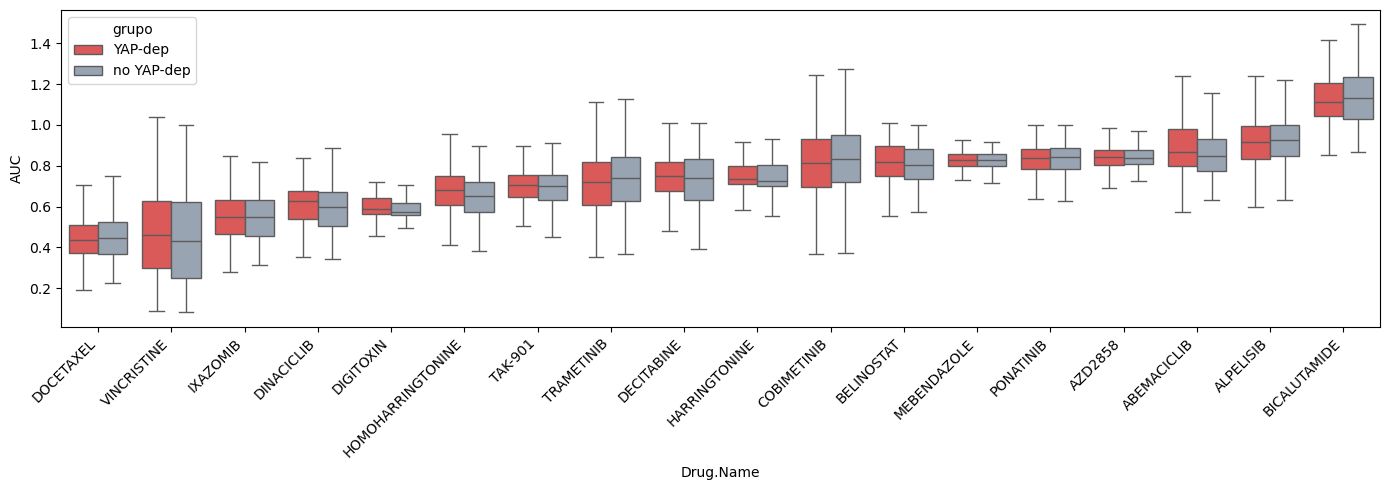

In [44]:

import seaborn as sns
import matplotlib.pyplot as plt

rows = []
for droga in drogas_mofa:
    for v in df_curve_param_f_ydep[df_curve_param_f_ydep['Drug.Name'] == droga]['auc'].dropna():
        rows.append({'Drug.Name': droga, 'AUC': v, 'grupo': 'YAP-dep'})
    for v in df_curve_param_f_noydep[df_curve_param_f_noydep['Drug.Name'] == droga]['auc'].dropna():
        rows.append({'Drug.Name': droga, 'AUC': v, 'grupo': 'no YAP-dep'})

df_plot = pd.DataFrame(rows)
orden = df_plot[df_plot['grupo']=='YAP-dep'].groupby('Drug.Name')['AUC'].mean().sort_values().index

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_plot, x='Drug.Name', y='AUC', hue='grupo',
            order=orden, palette={'YAP-dep': '#ef4444', 'no YAP-dep': '#94a3b8'},
            showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [39]:
matches = drogas_mofa & set(df_curve_param_f_ydep['Drug.Name'].dropna().unique())
print(f"Drogas MOFA presentes en secondary screen: {len(matches)}")
print(matches)


Drogas MOFA presentes en secondary screen: 18
{'BICALUTAMIDE', 'DOCETAXEL', 'TRAMETINIB', 'ABEMACICLIB', 'COBIMETINIB', 'TAK-901', 'MEBENDAZOLE', 'DIGITOXIN', 'VINCRISTINE', 'BELINOSTAT', 'DINACICLIB', 'ALPELISIB', 'AZD2858', 'PONATINIB', 'IXAZOMIB', 'HOMOHARRINGTONINE', 'DECITABINE', 'HARRINGTONINE'}


In [60]:
print(df_curve_param_f_ydep['depmap_id'].nunique())

265
